<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">Advanced Regression Diagnostics & Missing Topic Addendum</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.6; color:#e5e7eb;">
    This notebook closes the remaining coverage gaps from the Day 12 coverage matrix.
     
    It uses the same dataset families already used in the earlier notebooks: 
    Advertising, Bike Sharing, and Customer Campaign Response.
  </p>
  <p style="margin:10px 0 0 0; font-size:14px; color:#cbd5e1;">
   <b>Ruturaj Mokashi</b>
  </p>
</div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Notebook goal and coverage control</h3>
      <div style="color:#1f2937; font-size:14.5px;">
<p><b>Why this notebook exists:</b> the first four Day 12 notebooks cover the MVD and most professional additions. 
This notebook adds the remaining advanced diagnostic and theory topics so the final package has no open gaps.</p>
<ul>
  <li><b>Advertising dataset:</b> closed-form OLS, gradient descent, extrapolation risk, intervals, heteroscedasticity tests, robust standard errors, Cook's distance and leverage.</li>
  <li><b>Bike Sharing dataset:</b> Quasi-Poisson idea using overdispersion-adjusted standard errors.</li>
  <li><b>Customer Campaign Response dataset:</b> multinomial logistic regression extension using the same customer-style data from Notebook 4.</li>
</ul>
<p><b>Important:</b> these are add-on topics. They strengthen the project, but they do not replace the four main notebooks.</p>
</div>
    </div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 1 — Project setup and print-ready helpers</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell creates clean relative folders and reusable HTML helper functions. 
The helpers keep the notebook visually consistent with the approved Day 12 V3 notebooks.
</div>
    </div>

In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND PRINT-READY DISPLAY HELPERS
# ============================================================

# pathlib creates clean relative paths without exposing personal folders.
from pathlib import Path

# HTML and display let us create formatted conclusion boxes in notebook outputs.
from IPython.display import HTML, display

# PROJECT_DIR is the folder where this notebook is running.
PROJECT_DIR = Path.cwd()

# DATA_DIR is where optional local datasets can be placed.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR can store optional charts or exported files.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create folders safely if they do not exist.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# This helper shows green output-aware conclusion boxes after code cells.
def show_conclusion(title, body):
    """Display a print-ready green conclusion box."""
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:14px 18px; 
                border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#166534;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

# This helper shows blue information boxes when a code cell needs a warning or explanation.
def show_info(title, body):
    """Display a print-ready blue information box."""
    display(HTML(f"""
    <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:14px 18px; 
                border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#1e40af;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

show_conclusion(
    "Setup complete",
    "Project folders and HTML helpers are ready. The notebook will use relative paths only, so it remains portable and does not expose personal folders."
)

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 2 — Import libraries</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell imports the tools needed for advanced regression diagnostics. 
We use <b>sklearn</b> for prediction-focused modelling, <b>statsmodels</b> for statistical diagnostics, and <b>matplotlib</b> for print-ready charts.
</div>
    </div>

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# Core table and numeric tools.
import numpy as np
import pandas as pd

# Matplotlib is used for stable print-ready charts.
import matplotlib.pyplot as plt

# Warnings are filtered to keep the notebook output readable.
import warnings
warnings.filterwarnings("ignore")

# Scipy provides formal statistical tests.
from scipy import stats

# sklearn models and workflow tools.
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# statsmodels provides OLS diagnostics, robust standard errors and GLM tools.
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence

# Pandas display settings make tables easier to read.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

show_conclusion(
    "Libraries imported",
    "All required tools are available for closed-form OLS, gradient descent demonstration, residual diagnostics, robust standard errors, Quasi-Poisson and multinomial logistic regression."
)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-wh28ma5r because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


<div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; font-family:Arial, sans-serif; margin:22px 0 14px 0;">
  <h2 style="margin:0; font-size:23px;">Part A — Advertising dataset addendum</h2>
  <p style="margin:8px 0 0 0; color:#d1d5db; font-size:14.5px; line-height:1.55;">This section uses the same Advertising dataset logic from Notebook 1. It adds the advanced OLS and diagnostics topics that were still missing from the coverage matrix.</p>
</div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 3 — Load Advertising dataset safely</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell uses the same idea as Notebook 1: first look for a local Advertising CSV, then create a deterministic fallback dataset only if the local file is not available. 
The required columns are <code>TV</code>, <code>Radio</code>, <code>Newspaper</code>, and <code>Sales</code>.
</div>
    </div>

In [3]:
# ============================================================
# CELL 3 — LOAD ADVERTISING DATASET SAFELY
# ============================================================

# Candidate paths cover common local file names.
candidate_paths = [
    DATA_DIR / "Advertising.csv",
    DATA_DIR / "advertising.csv",
    PROJECT_DIR / "Advertising.csv",
    PROJECT_DIR / "advertising.csv",
]

# Search for the first available Advertising CSV file.
selected_data_path = None
for path in candidate_paths:
    if path.exists():
        selected_data_path = path
        break

# Load a local file if available; otherwise create the same kind of deterministic fallback dataset.
if selected_data_path is not None:
    advertising_df = pd.read_csv(selected_data_path)
    advertising_source = f"Local file: {selected_data_path.name}"
else:
    # The fallback data is only for stable execution when the Kaggle file is not present.
    rng = np.random.default_rng(42)
    n_rows = 200

    # Create realistic advertising budget ranges.
    tv_budget = rng.uniform(0, 300, n_rows)
    radio_budget = rng.uniform(0, 50, n_rows)
    newspaper_budget = rng.uniform(0, 115, n_rows)

    # Create Sales using a known linear signal plus noise.
    sales = 3.0 + 0.045 * tv_budget + 0.185 * radio_budget + 0.002 * newspaper_budget + rng.normal(0, 1.4, n_rows)

    # Store the fallback data in the same column structure as the Advertising dataset.
    advertising_df = pd.DataFrame({
        "TV": tv_budget,
        "Radio": radio_budget,
        "Newspaper": newspaper_budget,
        "Sales": sales
    })
    advertising_source = "Deterministic fallback Advertising-style dataset"

print("Advertising data source:", advertising_source)
print("Shape:", advertising_df.shape)
display(advertising_df.head())

show_conclusion(
    "Advertising dataset loaded",
    f"The notebook is using <b>{advertising_source}</b>. The dataset has <b>{advertising_df.shape[0]:,}</b> rows and <b>{advertising_df.shape[1]}</b> columns."
)

Advertising data source: Deterministic fallback Advertising-style dataset
Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,232.186815,38.870242,34.721650,22.455975
1,131.663532,48.591321,105.620818,17.771971
2,257.579376,25.037059,89.848814,19.911462
3,209.210409,7.194875,12.717667,10.397065
4,28.253204,0.696814,114.658986,3.010736


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 4 — Clean and validate Advertising columns</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Before advanced diagnostics, we validate that the required columns are present and numeric. 
This keeps later cells stable and avoids silent modelling errors.
</div>
    </div>

In [4]:
# ============================================================
# CELL 4 — CLEAN AND VALIDATE ADVERTISING COLUMNS
# ============================================================

# Remove accidental index columns that sometimes appear in CSV exports.
index_like_columns = [col for col in advertising_df.columns if str(col).lower().startswith("unnamed")]
advertising_df = advertising_df.drop(columns=index_like_columns, errors="ignore")

# Standardize column names by removing accidental spaces.
advertising_df.columns = [str(col).strip() for col in advertising_df.columns]

# Required columns for this addendum.
required_columns = ["TV", "Radio", "Newspaper", "Sales"]

# Check for missing required columns.
missing_required_columns = [col for col in required_columns if col not in advertising_df.columns]
if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}. Expected: {required_columns}")

# Keep the columns in a stable order.
advertising_df = advertising_df[required_columns].copy()

# Convert all required columns to numeric.
for col in required_columns:
    advertising_df[col] = pd.to_numeric(advertising_df[col], errors="coerce")

# Drop rows with missing values in required columns.
rows_before = len(advertising_df)
advertising_df = advertising_df.dropna(subset=required_columns).reset_index(drop=True)
rows_after = len(advertising_df)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
display(advertising_df.describe().T.round(3))

show_conclusion(
    "Advertising data validated",
    f"The cleaned Advertising dataset has <b>{rows_after:,}</b> usable rows. All required variables are numeric and ready for OLS diagnostics."
)

Rows before cleaning: 200
Rows after cleaning: 200


,count,mean,std,min,25%,50%,75%,max
TV,200.0,148.161,84.693,2.209,75.665,143.701,224.173,297.713
Radio,200.0,24.961,14.420,0.615,11.836,25.271,38.326,49.332
Newspaper,200.0,56.910,33.614,0.624,26.569,58.036,85.481,114.897
Sales,200.0,14.309,4.958,3.011,11.006,14.304,17.901,26.815


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 5 — Fit sklearn and statsmodels OLS models</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell prepares one consistent multiple regression model using <code>TV</code>, <code>Radio</code>, and <code>Newspaper</code> to predict <code>Sales</code>. 
We fit the same relationship with both sklearn and statsmodels because the two libraries answer different questions.
</div>
    </div>

In [5]:
# ============================================================
# CELL 5 — FIT SKLEARN AND STATSMODELS OLS MODELS
# ============================================================

# Feature columns are the advertising channels.
feature_columns = ["TV", "Radio", "Newspaper"]

# X contains input features; y contains the numeric target.
X_ad = advertising_df[feature_columns].copy()
y_ad = advertising_df["Sales"].copy()

# Fit sklearn LinearRegression for prediction-focused coefficients.
sklearn_ols = LinearRegression()
sklearn_ols.fit(X_ad, y_ad)

# Add an intercept column for statsmodels.
X_ad_sm = sm.add_constant(X_ad)

# Fit statsmodels OLS for statistical inference and diagnostics.
statsmodels_ols = sm.OLS(y_ad, X_ad_sm).fit()

# Compare basic coefficients from both libraries.
coef_compare = pd.DataFrame({
    "feature": ["Intercept"] + feature_columns,
    "sklearn_coefficient": [sklearn_ols.intercept_] + list(sklearn_ols.coef_),
    "statsmodels_coefficient": statsmodels_ols.params.values
}).round(6)

display(coef_compare)

show_conclusion(
    "sklearn and statsmodels models fitted",
    "Both libraries estimated the same linear relationship. sklearn is mainly prediction-focused, while statsmodels gives inference tools such as p-values, confidence intervals, residual tests and influence diagnostics."
)

,feature,sklearn_coefficient,statsmodels_coefficient
0,Intercept,2.771893,2.771893
1,TV,0.046202,0.046202
2,Radio,0.192916,0.192916
3,Newspaper,-0.002170,-0.002170


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 6 — Normal equation / closed-form OLS</h3>
      <div style="color:#1f2937; font-size:14.5px;">
The normal equation is the matrix version of OLS. It solves the best coefficients directly instead of learning them step by step. 
This answers the missing topic: <b>normal equation / matrix OLS form</b>.
</div>
    </div>

In [6]:
# ============================================================
# CELL 6 — NORMAL EQUATION / CLOSED-FORM OLS
# ============================================================

# Convert the statsmodels design matrix into a NumPy array.
X_matrix = X_ad_sm.to_numpy()

# Convert the target into a NumPy array.
y_vector = y_ad.to_numpy()

# Closed-form OLS solution: beta = (X'X)^(-1)X'y.
# np.linalg.pinv is used instead of inverse because it is numerically safer.
beta_closed_form = np.linalg.pinv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_vector

# Compare closed-form coefficients with statsmodels coefficients.
closed_form_table = pd.DataFrame({
    "term": ["Intercept"] + feature_columns,
    "closed_form_beta": beta_closed_form,
    "statsmodels_beta": statsmodels_ols.params.values,
    "absolute_difference": np.abs(beta_closed_form - statsmodels_ols.params.values)
}).round(10)

display(closed_form_table)

max_difference = closed_form_table["absolute_difference"].max()

show_conclusion(
    "Closed-form OLS confirmed",
    f"The largest coefficient difference between the matrix formula and statsmodels is <b>{max_difference:.10f}</b>. This shows that statsmodels OLS is solving the same least-squares problem."
)

,term,closed_form_beta,statsmodels_beta,absolute_difference
0,Intercept,2.771893,2.771893,0.0
1,TV,0.046202,0.046202,0.0
2,Radio,0.192916,0.192916,0.0
3,Newspaper,-0.002170,-0.002170,0.0


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 7 — Gradient descent setup for simple regression</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Closed-form OLS jumps directly to the answer. Gradient descent reaches the answer gradually by reducing the error step by step. 
To keep the demonstration clear, we use a simple model: <code>TV → Sales</code>.
</div>
    </div>

In [7]:
# ============================================================
# CELL 7 — GRADIENT DESCENT SETUP FOR SIMPLE REGRESSION
# ============================================================

# Use only TV for a simple gradient descent demonstration.
tv_values = advertising_df[["TV"]].copy()
sales_values = advertising_df["Sales"].copy()

# Scale TV so gradient descent is stable and easy to understand.
tv_scaler = StandardScaler()
tv_scaled = tv_scaler.fit_transform(tv_values).ravel()

# Build the gradient descent design matrix with intercept and scaled TV.
X_gd = np.column_stack([np.ones(len(tv_scaled)), tv_scaled])

# Target stays in Sales units so the intercept remains meaningful.
y_gd = sales_values.to_numpy()

# Fit a sklearn simple regression on the same scaled TV for comparison.
sklearn_simple_scaled = LinearRegression()
sklearn_simple_scaled.fit(tv_scaled.reshape(-1, 1), y_gd)

print("Gradient descent matrix shape:", X_gd.shape)
print("Target shape:", y_gd.shape)

show_conclusion(
    "Gradient descent inputs prepared",
    "The design matrix contains an intercept column and one scaled TV column. This setup lets us show how coefficients move from a rough starting point toward the least-squares solution."
)

Gradient descent matrix shape: (200, 2)
Target shape: (200,)


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 8 — Run gradient descent and plot loss</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell performs gradient descent manually. 
The loss should decrease over iterations, showing how the model learns coefficients by repeatedly reducing squared error.
</div>
    </div>

,coefficient,gradient_descent,sklearn_closed_form
0,Intercept,14.30909,14.30909
1,Scaled TV slope,3.82693,3.82693


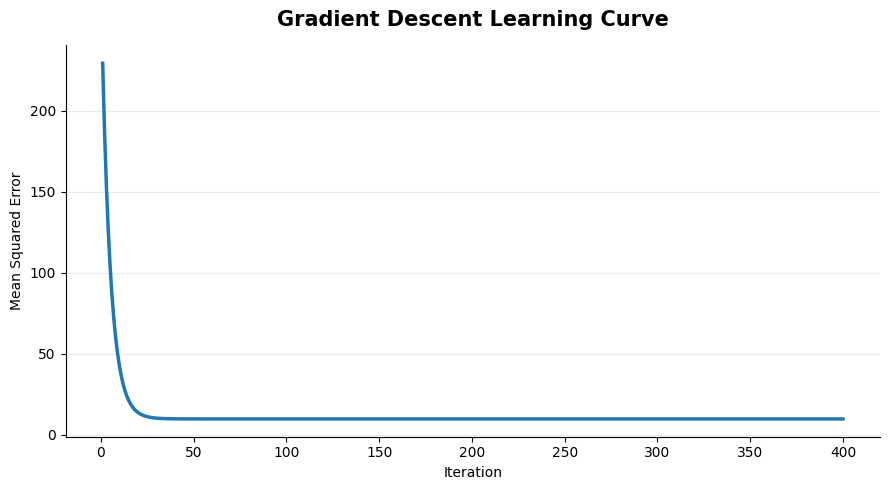

In [8]:
# ============================================================
# CELL 8 — RUN GRADIENT DESCENT AND PLOT LOSS
# ============================================================

# Initialize coefficients: beta[0] is intercept, beta[1] is TV slope.
beta = np.array([0.0, 0.0])

# Learning rate controls step size.
learning_rate = 0.05

# Number of updates.
n_iterations = 400

# Store loss values so we can plot learning progress.
loss_history = []

# Number of rows used in the gradient calculation.
n_rows = len(y_gd)

# Run gradient descent.
for iteration in range(n_iterations):
    # Predict Sales using current coefficients.
    predictions = X_gd @ beta

    # Calculate residuals.
    errors = predictions - y_gd

    # Calculate mean squared error.
    mse_loss = np.mean(errors ** 2)
    loss_history.append(mse_loss)

    # Calculate gradient of MSE with respect to beta.
    gradient = (2 / n_rows) * (X_gd.T @ errors)

    # Move coefficients in the opposite direction of the gradient.
    beta = beta - learning_rate * gradient

# Build coefficient comparison table.
gd_comparison = pd.DataFrame({
    "coefficient": ["Intercept", "Scaled TV slope"],
    "gradient_descent": beta,
    "sklearn_closed_form": [sklearn_simple_scaled.intercept_, sklearn_simple_scaled.coef_[0]]
}).round(5)

display(gd_comparison)

# Plot loss reduction.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_iterations + 1), loss_history, linewidth=2.5)
ax.set_title("Gradient Descent Learning Curve", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Squared Error")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

loss_drop = loss_history[0] - loss_history[-1]

show_conclusion(
    "Gradient descent vs closed-form solution",
    f"The loss dropped from <b>{loss_history[0]:.3f}</b> to <b>{loss_history[-1]:.3f}</b>. The learned coefficients are very close to the closed-form sklearn solution, but gradient descent reached them step by step."
)

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 9 — Interpolation vs extrapolation</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Interpolation means predicting inside the observed data range. Extrapolation means predicting outside the observed data range. 
Regression can technically do both, but extrapolation is riskier because the model has not seen that region of data.
</div>
    </div>

,TV,prediction_type,predicted_sales
0,2.21,Interpolation,7.70
1,143.70,Interpolation,14.11
2,297.71,Interpolation,21.08
3,372.14,Extrapolation,24.46


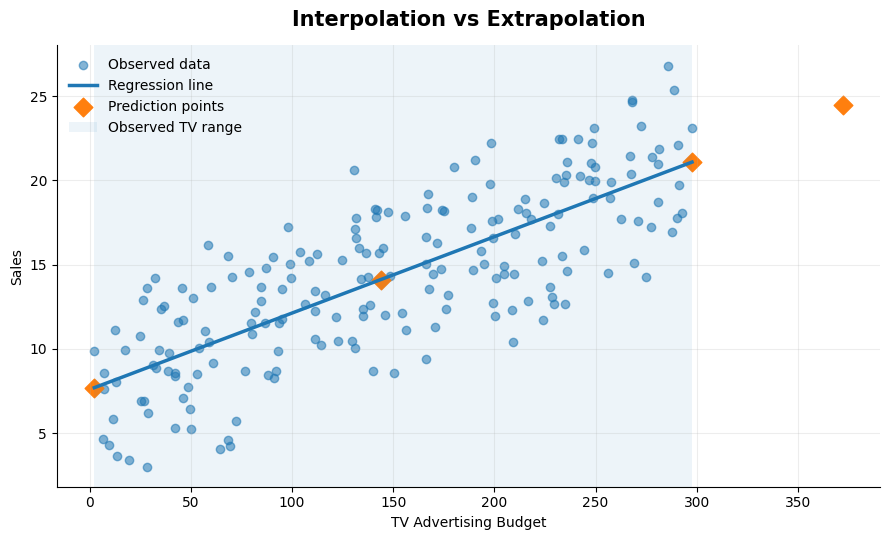

In [9]:
# ============================================================
# CELL 9 — INTERPOLATION VS EXTRAPOLATION
# ============================================================

# Fit a simple raw TV model so the prediction table is easy to read.
simple_tv_model = LinearRegression()
simple_tv_model.fit(advertising_df[["TV"]], advertising_df["Sales"])

# Identify observed TV range.
tv_min = advertising_df["TV"].min()
tv_max = advertising_df["TV"].max()
tv_mid = advertising_df["TV"].median()

# Create prediction points: two inside range and two outside range.
prediction_points = pd.DataFrame({
    "TV": [tv_min, tv_mid, tv_max, tv_max * 1.25]
})

# Label whether each point is interpolation or extrapolation.
prediction_points["prediction_type"] = np.where(
    prediction_points["TV"].between(tv_min, tv_max),
    "Interpolation",
    "Extrapolation"
)

# Predict Sales for the points.
prediction_points["predicted_sales"] = simple_tv_model.predict(prediction_points[["TV"]])
prediction_points = prediction_points.round({"TV": 2, "predicted_sales": 2})

display(prediction_points)

# Plot observed data and prediction points.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(advertising_df["TV"], advertising_df["Sales"], alpha=0.55, label="Observed data")
ax.plot(advertising_df["TV"].sort_values(), simple_tv_model.predict(advertising_df[["TV"]].sort_values("TV")), linewidth=2.5, label="Regression line")
ax.scatter(prediction_points["TV"], prediction_points["predicted_sales"], s=90, marker="D", label="Prediction points")

# Mark the observed data range.
ax.axvspan(tv_min, tv_max, alpha=0.08, label="Observed TV range")

ax.set_title("Interpolation vs Extrapolation", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("TV Advertising Budget")
ax.set_ylabel("Sales")
ax.grid(axis="both", alpha=0.22)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Interpolation and extrapolation warning",
    f"Predictions between <b>{tv_min:.1f}</b> and <b>{tv_max:.1f}</b> TV budget are interpolation. The point above <b>{tv_max:.1f}</b> is extrapolation, so it should be treated as a risky business assumption."
)

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 10 — Confidence interval vs prediction interval</h3>
      <div style="color:#1f2937; font-size:14.5px;">
A confidence interval estimates uncertainty around the <b>average expected Sales</b>. 
A prediction interval estimates uncertainty around <b>one future Sales observation</b>, so it is usually wider.
</div>
    </div>

In [10]:
# ============================================================
# CELL 10 — CONFIDENCE INTERVAL VS PREDICTION INTERVAL
# ============================================================

# Create three business scenarios using representative budget values.
scenario_df = pd.DataFrame({
    "TV": [advertising_df["TV"].quantile(0.25), advertising_df["TV"].median(), advertising_df["TV"].quantile(0.75)],
    "Radio": [advertising_df["Radio"].median()] * 3,
    "Newspaper": [advertising_df["Newspaper"].median()] * 3
})

# Add intercept column for statsmodels prediction.
scenario_sm = sm.add_constant(scenario_df, has_constant="add")

# Get confidence and prediction intervals from statsmodels.
prediction_frame = statsmodels_ols.get_prediction(scenario_sm).summary_frame(alpha=0.05)

# Combine scenarios and interval outputs.
interval_table = pd.concat([scenario_df.reset_index(drop=True), prediction_frame.reset_index(drop=True)], axis=1)
interval_table = interval_table.rename(columns={
    "mean": "predicted_mean_sales",
    "mean_ci_lower": "confidence_lower",
    "mean_ci_upper": "confidence_upper",
    "obs_ci_lower": "prediction_lower",
    "obs_ci_upper": "prediction_upper"
}).round(3)

display(interval_table)

# Compare average interval widths.
confidence_width = (interval_table["confidence_upper"] - interval_table["confidence_lower"]).mean()
prediction_width = (interval_table["prediction_upper"] - interval_table["prediction_lower"]).mean()

show_conclusion(
    "Prediction intervals are wider",
    f"The average confidence interval width is <b>{confidence_width:.2f}</b>, while the average prediction interval width is <b>{prediction_width:.2f}</b>. This is expected because individual future outcomes are more uncertain than the average trend."
)

,TV,Radio,Newspaper,predicted_mean_sales,mean_se,confidence_lower,confidence_upper,prediction_lower,prediction_upper
0,75.665,25.271,58.036,11.017,0.138,10.745,11.289,8.090,13.945
1,143.701,25.271,58.036,14.160,0.105,13.954,14.367,11.238,17.083
2,224.173,25.271,58.036,17.878,0.141,17.601,18.156,14.950,20.806


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 11 — Residual setup for diagnostics</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Residual diagnostics use the difference between actual Sales and predicted Sales. 
This cell prepares residuals, fitted values, standardized residuals, leverage, and Cook's distance for the next checks.
</div>
    </div>

In [11]:
# ============================================================
# CELL 11 — RESIDUAL SETUP FOR DIAGNOSTICS
# ============================================================

# Fitted values are model predictions on the observed rows.
fitted_sales = statsmodels_ols.fittedvalues

# Residuals are actual Sales minus fitted Sales.
ols_residuals = statsmodels_ols.resid

# Influence object calculates leverage, Cook's distance and standardized residuals.
influence = OLSInfluence(statsmodels_ols)

# Standardized residuals put residuals on a comparable scale.
standardized_residuals = influence.resid_studentized_internal

# Leverage shows how unusual a row is in feature space.
leverage_values = influence.hat_matrix_diag

# Cook's distance measures how strongly one row can influence the model.
cooks_distance = influence.cooks_distance[0]

# Build a diagnostic dataframe.
diagnostic_df = advertising_df.copy()
diagnostic_df["fitted_sales"] = fitted_sales
diagnostic_df["residual"] = ols_residuals
diagnostic_df["standardized_residual"] = standardized_residuals
diagnostic_df["leverage"] = leverage_values
diagnostic_df["cooks_distance"] = cooks_distance

display(diagnostic_df[["Sales", "fitted_sales", "residual", "standardized_residual", "leverage", "cooks_distance"]].head().round(4))

show_conclusion(
    "Residual diagnostics prepared",
    "The diagnostic dataframe now contains fitted values, residuals, standardized residuals, leverage and Cook's distance. These variables help check model assumptions and influential rows."
)

,Sales,fitted_sales,residual,standardized_residual,leverage,cooks_distance
0,22.4560,20.9227,1.5333,1.0469,0.0180,0.0050
1,17.7720,17.9998,-0.2278,-0.1563,0.0278,0.0002
2,19.9115,19.3076,0.6039,0.4122,0.0175,0.0008
3,10.3971,13.7982,-3.4011,-2.3284,0.0232,0.0322
4,3.0107,3.9629,-0.9521,-0.6605,0.0486,0.0056


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 12 — Homoscedasticity vs heteroscedasticity visual check</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Homoscedasticity means residuals have roughly equal spread across prediction levels. 
Heteroscedasticity means the spread changes, often forming a funnel shape. This matters because unequal spread can make standard errors and p-values less trustworthy.
</div>
    </div>

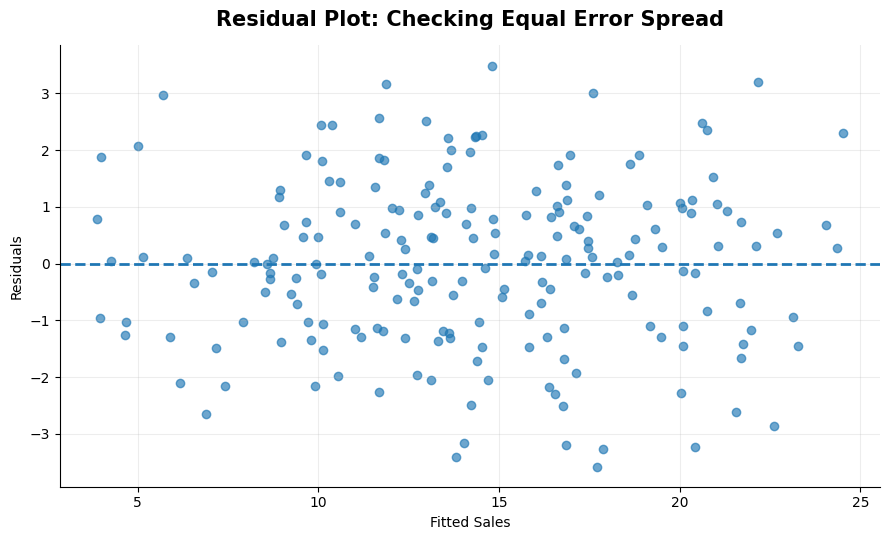

,fitted_bucket,count,std
0,"(3.879, 11.019]",50,1.348
1,"(11.019, 14.204]",50,1.484
2,"(14.204, 17.494]",50,1.451
3,"(17.494, 24.51]",50,1.613


In [12]:
# ============================================================
# CELL 12 — HOMOSCEDASTICITY VS HETEROSCEDASTICITY VISUAL CHECK
# ============================================================

# Create a residual plot using fitted values on the x-axis.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(diagnostic_df["fitted_sales"], diagnostic_df["residual"], alpha=0.65)
ax.axhline(0, linewidth=2, linestyle="--")

# Add labels and professional formatting.
ax.set_title("Residual Plot: Checking Equal Error Spread", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Fitted Sales")
ax.set_ylabel("Residuals")
ax.grid(axis="both", alpha=0.22)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Calculate residual spread in fitted-value quartiles.
diagnostic_df["fitted_bucket"] = pd.qcut(diagnostic_df["fitted_sales"], q=4, duplicates="drop")
spread_table = (
    diagnostic_df.groupby("fitted_bucket", observed=False)["residual"]
    .agg(["count", "std"])
    .reset_index()
)
spread_table["std"] = spread_table["std"].round(3)

display(spread_table)

spread_ratio = spread_table["std"].max() / spread_table["std"].min()

show_conclusion(
    "Homoscedasticity visual check completed",
    f"The largest residual spread bucket is about <b>{spread_ratio:.2f}×</b> the smallest bucket. A very large ratio or clear funnel shape would suggest heteroscedasticity."
)

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 13 — Formal residual normality tests</h3>
      <div style="color:#1f2937; font-size:14.5px;">
QQ plots are visual. Formal tests add a numerical check. 
Here we use Jarque-Bera and Shapiro-Wilk as notes beside the QQ/residual diagnostics.
</div>
    </div>

In [13]:
# ============================================================
# CELL 13 — FORMAL RESIDUAL NORMALITY TESTS
# ============================================================

# Jarque-Bera checks skewness and kurtosis against a normal distribution.
jarque_bera_result = stats.jarque_bera(ols_residuals)

# Shapiro-Wilk is another normality test. It is fine here because the dataset is small.
shapiro_result = stats.shapiro(ols_residuals)

# Build a compact interpretation table.
normality_tests = pd.DataFrame({
    "test": ["Jarque-Bera", "Shapiro-Wilk"],
    "statistic": [jarque_bera_result.statistic, shapiro_result.statistic],
    "p_value": [jarque_bera_result.pvalue, shapiro_result.pvalue],
})
normality_tests["normality_flag"] = np.where(
    normality_tests["p_value"] < 0.05,
    "Reject normality at 5%",
    "No strong rejection at 5%"
)

display(normality_tests.round(5))

show_conclusion(
    "Formal normality tests completed",
    "A low p-value suggests residuals deviate from normality. In business modelling, this matters more for inference and intervals than for basic prediction accuracy."
)

,test,statistic,p_value,normality_flag
0,Jarque-Bera,1.40612,0.49507,No strong rejection at 5%
1,Shapiro-Wilk,0.99323,0.49065,No strong rejection at 5%


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 14 — Breusch-Pagan heteroscedasticity test</h3>
      <div style="color:#1f2937; font-size:14.5px;">
The Breusch-Pagan test is a formal test for heteroscedasticity. 
It checks whether residual variance is related to the model features.
</div>
    </div>

In [14]:
# ============================================================
# CELL 14 — BREUSCH-PAGAN HETEROSCEDASTICITY TEST
# ============================================================

# Run Breusch-Pagan using residuals and the OLS design matrix.
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(ols_residuals, X_ad_sm)

# Store results in a readable table.
bp_table = pd.DataFrame({
    "metric": ["LM statistic", "LM p-value", "F statistic", "F p-value"],
    "value": [bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue]
}).round(5)

display(bp_table)

# Create a simple interpretation.
if bp_f_pvalue < 0.05:
    bp_message = "The test suggests heteroscedasticity at the 5% level. Robust standard errors should be considered."
else:
    bp_message = "The test does not strongly suggest heteroscedasticity at the 5% level."

show_conclusion(
    "Breusch-Pagan test completed",
    bp_message
)

,metric,value
0,LM statistic,2.77689
1,LM p-value,0.42732
2,F statistic,0.91989
3,F p-value,0.43223


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 15 — Robust standard errors</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Robust standard errors help when residual variance is not constant. 
They usually do not change the coefficients, but they can change standard errors, t-values, p-values, and therefore inference.
</div>
    </div>

In [15]:
# ============================================================
# CELL 15 — ROBUST STANDARD ERRORS
# ============================================================

# Get HC3 robust standard errors from the same OLS model.
robust_ols = statsmodels_ols.get_robustcov_results(cov_type="HC3")

# Build comparison table for coefficients, standard errors and p-values.
robust_table = pd.DataFrame({
    "term": statsmodels_ols.params.index,
    "coefficient": statsmodels_ols.params.values,
    "standard_se": statsmodels_ols.bse.values,
    "robust_hc3_se": robust_ols.bse,
    "standard_p_value": statsmodels_ols.pvalues.values,
    "robust_p_value": robust_ols.pvalues
}).round(5)

display(robust_table)

show_conclusion(
    "Robust standard errors compared",
    "The coefficient estimates stay the same, but the standard errors and p-values can change. This is why robust standard errors are useful when heteroscedasticity may exist."
)

,term,coefficient,standard_se,robust_hc3_se,standard_p_value,robust_p_value
0,const,2.77189,0.32089,0.34030,0.00000,0.00000
1,TV,0.04620,0.00124,0.00124,0.00000,0.00000
2,Radio,0.19292,0.00729,0.00749,0.00000,0.00000
3,Newspaper,-0.00217,0.00313,0.00307,0.48895,0.48093


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 16 — Cook's distance and leverage table</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Leverage finds unusual feature combinations. Cook's distance shows whether a row strongly affects the fitted model. 
A row can be unusual without being influential, so both measures are useful together.
</div>
    </div>

In [16]:
# ============================================================
# CELL 16 — COOK'S DISTANCE AND LEVERAGE TABLE
# ============================================================

# Common Cook's distance rule-of-thumb threshold.
cooks_threshold = 4 / len(diagnostic_df)

# Common high leverage rule of thumb: 2p/n, where p includes the intercept.
p_parameters = X_ad_sm.shape[1]
leverage_threshold = 2 * p_parameters / len(diagnostic_df)

# Get top influential rows by Cook's distance.
top_influence = (
    diagnostic_df
    .assign(row_id=lambda df: df.index)
    .sort_values("cooks_distance", ascending=False)
    [["row_id", "TV", "Radio", "Newspaper", "Sales", "fitted_sales", "residual", "leverage", "cooks_distance"]]
    .head(10)
    .round(4)
)

display(top_influence)

# Count rows above thresholds.
high_cooks_count = int((diagnostic_df["cooks_distance"] > cooks_threshold).sum())
high_leverage_count = int((diagnostic_df["leverage"] > leverage_threshold).sum())

show_conclusion(
    "Influential rows identified",
    f"Using rule-of-thumb thresholds, <b>{high_cooks_count}</b> rows exceed Cook's distance threshold and <b>{high_leverage_count}</b> rows exceed the leverage threshold. These rows should be reviewed before making final coefficient claims."
)

,row_id,TV,Radio,Newspaper,Sales,fitted_sales,residual,leverage,cooks_distance
22,22,291.2094,33.1432,0.6244,19.7522,22.6188,-2.8665,0.0379,0.0385
3,3,209.2104,7.1949,12.7177,10.3971,13.7982,-3.4011,0.0232,0.0322
8,8,38.4341,6.0916,12.2382,8.6772,5.6962,2.9809,0.0293,0.0316
54,54,211.5496,11.8331,10.5479,18.2990,14.8058,3.4933,0.0212,0.0309
119,119,188.1927,47.4429,95.1249,17.1874,20.4128,-3.2254,0.0236,0.0295
176,176,130.5291,46.8064,104.5985,20.6104,17.6053,3.0052,0.0256,0.0279
92,92,133.8469,46.2421,75.0298,14.1373,17.7139,-3.5766,0.0170,0.0258
99,99,288.5693,32.1242,58.9650,25.3822,22.1736,3.2086,0.0203,0.0249
162,162,69.0642,5.8552,97.0127,4.2389,6.8818,-2.6429,0.0277,0.0234
194,194,45.9853,0.6151,0.8412,7.0877,5.0133,2.0744,0.0382,0.0204


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 17 — Cook's distance and leverage chart</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This chart shows which rows deserve attention. 
Rows with high leverage and large residuals are often the most important to review.
</div>
    </div>

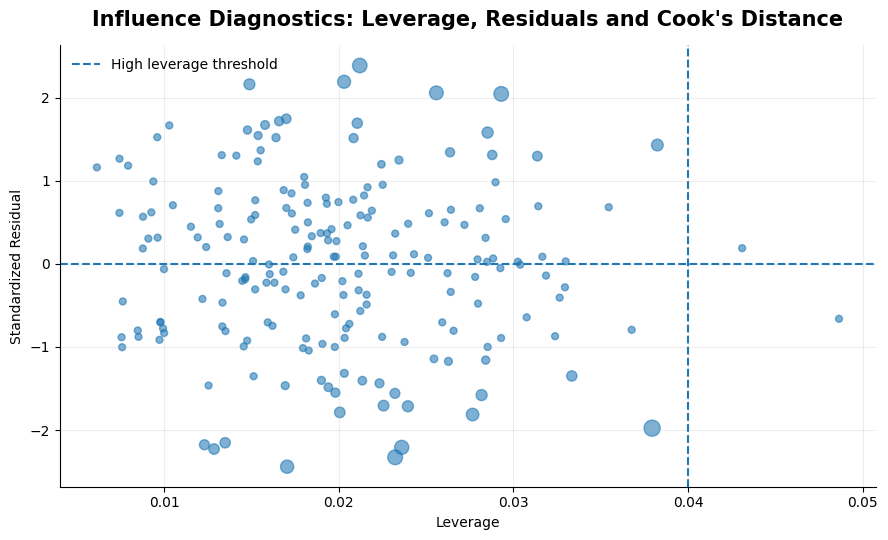

In [17]:
# ============================================================
# CELL 17 — COOK'S DISTANCE AND LEVERAGE CHART
# ============================================================

# Create leverage vs standardized residual plot.
fig, ax = plt.subplots(figsize=(9, 5.5))
scatter = ax.scatter(
    diagnostic_df["leverage"],
    diagnostic_df["standardized_residual"],
    s=np.maximum(diagnostic_df["cooks_distance"] * 3500, 25),
    alpha=0.58
)

# Add reference lines.
ax.axhline(0, linestyle="--", linewidth=1.5)
ax.axvline(leverage_threshold, linestyle="--", linewidth=1.5, label="High leverage threshold")

# Format chart.
ax.set_title("Influence Diagnostics: Leverage, Residuals and Cook's Distance", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized Residual")
ax.grid(axis="both", alpha=0.22)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Influence chart completed",
    "Larger circles have higher Cook's distance. Points far right have high leverage, while points far from zero have large standardized residuals. These are the rows that can move the regression line most."
)

<div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; font-family:Arial, sans-serif; margin:22px 0 14px 0;">
  <h2 style="margin:0; font-size:23px;">Part B — Bike Sharing Quasi-Poisson addendum</h2>
  <p style="margin:8px 0 0 0; color:#d1d5db; font-size:14.5px; line-height:1.55;">This section uses the same Bike Sharing dataset logic from Notebook 3. It adds the missing Quasi-Poisson explanation using overdispersion-adjusted standard errors.</p>
</div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 18 — Load Bike Sharing dataset safely</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell follows the same strategy as Notebook 3: look for local Bike Sharing files first, then create a deterministic fallback. 
We use it only to demonstrate how Quasi-Poisson thinking handles overdispersion.
</div>
    </div>

In [18]:
# ============================================================
# CELL 18 — LOAD BIKE SHARING DATASET SAFELY
# ============================================================

# Candidate Bike Sharing files used in earlier notebook logic.
bike_candidate_files = [
    DATA_DIR / "hour.csv",
    DATA_DIR / "day.csv",
    DATA_DIR / "bike_sharing.csv",
    DATA_DIR / "bike_sharing_hour.csv",
    DATA_DIR / "Bike-Sharing-Dataset" / "hour.csv",
    DATA_DIR / "Bike-Sharing-Dataset" / "day.csv",
]

# Try local files first.
bike_df = None
bike_source = None

for file_path in bike_candidate_files:
    if file_path.exists():
        possible_df = pd.read_csv(file_path)
        if "cnt" in possible_df.columns:
            bike_df = possible_df.copy()
            bike_source = f"Local file: {file_path.name}"
            break

# Fallback dataset if no local Bike Sharing file exists.
if bike_df is None:
    rng = np.random.default_rng(42)
    n_rows = 900
    dates = pd.date_range("2011-01-01", periods=n_rows, freq="H")

    # Calendar and weather-style features.
    hour = dates.hour
    month = dates.month
    weekday = dates.weekday
    workingday = (weekday < 5).astype(int)
    temp = 0.45 + 0.25 * np.sin(2 * np.pi * (month - 3) / 12) + rng.normal(0, 0.08, n_rows)
    hum = np.clip(0.60 + rng.normal(0, 0.12, n_rows), 0.25, 0.95)
    windspeed = np.clip(rng.gamma(2.0, 0.08, n_rows), 0.01, 0.55)

    # Count target with overdispersion using a Gamma-Poisson style multiplier.
    base_rate = np.exp(3.1 + 0.35 * workingday + 0.02 * hour + 1.2 * temp - 0.8 * hum)
    overdispersion_multiplier = rng.gamma(shape=2.0, scale=0.5, size=n_rows)
    cnt = rng.poisson(base_rate * overdispersion_multiplier)

    bike_df = pd.DataFrame({
        "hr": hour,
        "mnth": month,
        "weekday": weekday,
        "workingday": workingday,
        "temp": temp,
        "hum": hum,
        "windspeed": windspeed,
        "cnt": cnt
    })
    bike_source = "Deterministic fallback Bike Sharing-style dataset"

print("Bike data source:", bike_source)
print("Shape:", bike_df.shape)
display(bike_df.head())

show_conclusion(
    "Bike Sharing dataset loaded",
    f"The Bike Sharing addendum is using <b>{bike_source}</b>. The target <code>cnt</code> is available for Poisson and Quasi-Poisson demonstration."
)

Bike data source: Deterministic fallback Bike Sharing-style dataset
Shape: (900, 8)


,hr,mnth,weekday,workingday,temp,hum,windspeed,cnt
0,0,1,5,0,0.257871,0.646763,0.129274,21
1,1,1,5,0,0.150295,0.612306,0.104299,9
2,2,1,5,0,0.293530,0.582307,0.143101,33
3,3,1,5,0,0.308739,0.790593,0.188919,57
4,4,1,5,0,0.077411,0.525335,0.137475,6


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 19 — Quasi-Poisson overdispersion adjustment</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Poisson assumes the count mean and variance are similar. 
Quasi-Poisson keeps the Poisson mean structure but inflates standard errors when the data is overdispersed.
</div>
    </div>

In [19]:
# ============================================================
# CELL 19 — QUASI-POISSON OVERDISPERSION ADJUSTMENT
# ============================================================

# Choose safe numeric features that exist in the current Bike Sharing dataframe.
bike_features = [col for col in ["hr", "mnth", "weekday", "workingday", "temp", "hum", "windspeed"] if col in bike_df.columns]

# Keep only required columns and drop missing values.
bike_model_df = bike_df[bike_features + ["cnt"]].dropna().copy()

# Build design matrix and target.
X_bike = sm.add_constant(bike_model_df[bike_features], has_constant="add")
y_bike = bike_model_df["cnt"]

# Fit standard Poisson GLM.
poisson_glm = sm.GLM(y_bike, X_bike, family=sm.families.Poisson()).fit()

# Fit the same Poisson mean model but estimate scale from Pearson chi-square.
quasi_poisson_glm = sm.GLM(y_bike, X_bike, family=sm.families.Poisson()).fit(scale="X2")

# Calculate mean, variance and dispersion.
bike_mean = y_bike.mean()
bike_variance = y_bike.var()
variance_mean_ratio = bike_variance / bike_mean if bike_mean > 0 else np.nan
pearson_dispersion = poisson_glm.pearson_chi2 / poisson_glm.df_resid

# Compare first few standard errors.
se_compare = pd.DataFrame({
    "term": poisson_glm.params.index,
    "poisson_coefficient": poisson_glm.params.values,
    "poisson_se": poisson_glm.bse.values,
    "quasi_poisson_se": quasi_poisson_glm.bse.values,
    "se_inflation": quasi_poisson_glm.bse.values / poisson_glm.bse.values
}).round(5)

display(pd.DataFrame({
    "metric": ["Mean cnt", "Variance cnt", "Variance / Mean", "Pearson dispersion"],
    "value": [bike_mean, bike_variance, variance_mean_ratio, pearson_dispersion]
}).round(4))

display(se_compare.head(8))

show_conclusion(
    "Quasi-Poisson note completed",
    f"The variance/mean ratio is <b>{variance_mean_ratio:.2f}</b> and Pearson dispersion is <b>{pearson_dispersion:.2f}</b>. Quasi-Poisson keeps the count-model logic but adjusts uncertainty when overdispersion exists."
)

,metric,value
0,Mean cnt,30.0322
1,Variance cnt,615.2392
2,Variance / Mean,20.4860
3,Pearson dispersion,15.3432


,term,poisson_coefficient,poisson_se,quasi_poisson_se,se_inflation
0,const,3.21689,0.04830,0.18918,3.91703
1,hr,0.02488,0.00089,0.00347,3.91703
2,mnth,0.01732,0.01702,0.06667,3.91703
3,weekday,0.00957,0.00483,0.01891,3.91703
4,workingday,0.43056,0.02217,0.08684,3.91703
5,temp,1.21030,0.07739,0.30313,3.91703
6,hum,-1.29006,0.05015,0.19642,3.91703
7,windspeed,-0.14254,0.05535,0.21681,3.91703


<div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; font-family:Arial, sans-serif; margin:22px 0 14px 0;">
  <h2 style="margin:0; font-size:23px;">Part C — Customer Campaign Response multinomial logistic addendum</h2>
  <p style="margin:8px 0 0 0; color:#d1d5db; font-size:14.5px; line-height:1.55;">This section uses the same customer campaign dataset style from Notebook 4. It adds the missing note on binary vs multinomial logistic regression.</p>
</div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 20 — Load Customer Campaign Response dataset safely</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Notebook 4 used a customer campaign response dataset for binary logistic regression. 
Here we reuse the same data style and create an educational three-class business target for multinomial logistic regression.
</div>
    </div>

In [20]:
# ============================================================
# CELL 20 — LOAD CUSTOMER CAMPAIGN RESPONSE DATASET SAFELY
# ============================================================

# Local dataset path from Notebook 4.
campaign_file = DATA_DIR / "customer_campaign_response.csv"

# Create or load the campaign-style data.
if campaign_file.exists():
    customer_df = pd.read_csv(campaign_file)
    campaign_source = "Local file: data/customer_campaign_response.csv"
else:
    rng = np.random.default_rng(42)
    n_customers = 1600

    # Numeric customer behavior signals.
    age = rng.integers(21, 68, n_customers)
    tenure_months = rng.integers(1, 84, n_customers)
    monthly_spend = np.round(rng.gamma(shape=4.0, scale=18.0, size=n_customers) + 20, 2)
    website_visits = rng.poisson(lam=5, size=n_customers)
    email_clicks = rng.poisson(lam=2, size=n_customers)
    discount_interest = rng.beta(a=2.0, b=4.0, size=n_customers)

    # Categorical customer attributes.
    region = rng.choice(["North", "South", "East", "West"], size=n_customers, p=[0.25, 0.25, 0.25, 0.25])
    device_type = rng.choice(["Mobile", "Desktop", "Tablet"], size=n_customers, p=[0.55, 0.35, 0.10])

    # Response probability using a realistic marketing signal.
    linear_score = (
        -2.4
        + 0.018 * monthly_spend
        + 0.16 * website_visits
        + 0.35 * email_clicks
        + 1.10 * discount_interest
        - 0.006 * age
    )
    response_probability = 1 / (1 + np.exp(-linear_score))
    responded = rng.binomial(1, response_probability)

    customer_df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "monthly_spend": monthly_spend,
        "website_visits": website_visits,
        "email_clicks": email_clicks,
        "discount_interest": discount_interest,
        "region": region,
        "device_type": device_type,
        "responded": responded
    })
    campaign_source = "Deterministic fallback Customer Campaign Response-style dataset"

print("Campaign data source:", campaign_source)
print("Shape:", customer_df.shape)
display(customer_df.head())

show_conclusion(
    "Customer campaign dataset loaded",
    f"The multinomial addendum is using <b>{campaign_source}</b>. This keeps the logistic regression extension aligned with Notebook 4."
)

Campaign data source: Deterministic fallback Customer Campaign Response-style dataset
Shape: (1600, 9)


,age,tenure_months,monthly_spend,website_visits,email_clicks,discount_interest,region,device_type,responded
0,25,26,73.39,1,1,0.612774,East,Desktop,1
1,57,62,61.67,6,2,0.306643,North,Desktop,1
2,51,69,58.61,5,1,0.269019,East,Mobile,1
3,41,27,53.47,6,3,0.133784,North,Desktop,1
4,41,11,114.48,6,0,0.321157,South,Desktop,1


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 21 — Create a three-class response priority target</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Binary logistic regression predicts two classes. Multinomial logistic regression predicts more than two classes. 
To demonstrate this using the same customer dataset, we create a business-friendly target: <b>Low priority</b>, <b>Nurture</b>, and <b>High intent</b>.
</div>
    </div>

In [21]:
# ============================================================
# CELL 21 — CREATE THREE-CLASS RESPONSE PRIORITY TARGET
# ============================================================

# Copy the customer dataframe so the original binary target stays unchanged.
multi_df = customer_df.copy()

# Define high-intent signals using customer behavior.
high_spend_cutoff = multi_df["monthly_spend"].quantile(0.70)
high_click_cutoff = multi_df["email_clicks"].quantile(0.70)
high_discount_cutoff = multi_df["discount_interest"].quantile(0.70)

# Start everyone as Low priority.
multi_df["response_priority"] = "Low priority"

# Nurture customers have some engagement or already responded.
nurture_condition = (
    (multi_df["website_visits"] >= multi_df["website_visits"].median()) |
    (multi_df["email_clicks"] >= multi_df["email_clicks"].median()) |
    (multi_df["responded"] == 1)
)
multi_df.loc[nurture_condition, "response_priority"] = "Nurture"

# High intent customers show stronger buying/engagement signals.
high_intent_condition = (
    (multi_df["responded"] == 1) &
    (
        (multi_df["monthly_spend"] >= high_spend_cutoff) |
        (multi_df["email_clicks"] >= high_click_cutoff) |
        (multi_df["discount_interest"] >= high_discount_cutoff)
    )
)
multi_df.loc[high_intent_condition, "response_priority"] = "High intent"

# Display target distribution.
priority_counts = multi_df["response_priority"].value_counts().reset_index()
priority_counts.columns = ["response_priority", "customers"]
priority_counts["share"] = priority_counts["customers"] / len(multi_df)

display(priority_counts)

show_conclusion(
    "Multiclass target created",
    "The new target has three business classes. This lets us show how logistic regression extends from binary classification to multinomial classification."
)

,response_priority,customers,share
0,High intent,772,0.482500
1,Nurture,707,0.441875
2,Low priority,121,0.075625


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 22 — Train multinomial Logistic Regression</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell trains a multinomial logistic regression model. 
The workflow is intentionally similar to Notebook 4: preprocessing inside a pipeline, stratified split, and clean evaluation on unseen test data.
</div>
    </div>

In [22]:
# ============================================================
# CELL 22 — TRAIN MULTINOMIAL LOGISTIC REGRESSION
# ============================================================

# Target for multinomial classification.
multi_target = "response_priority"

# Remove binary responded to avoid making the engineered target too easy.
X_multi = multi_df.drop(columns=[multi_target, "responded"])
y_multi = multi_df[multi_target]

# Separate numeric and categorical features.
numeric_multi_features = X_multi.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_multi_features = X_multi.select_dtypes(include=["object", "category"]).columns.tolist()

# Stratified split preserves class balance.
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=42,
    stratify=y_multi
)

# OneHotEncoder syntax differs across sklearn versions.
try:
    multi_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    multi_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Preprocess numeric and categorical columns.
multi_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_multi_features),
        ("cat", multi_encoder, categorical_multi_features)
    ]
)

# Multinomial Logistic Regression model.\n# Recent sklearn versions automatically handle multiclass targets here.
multi_logistic_model = Pipeline(steps=[
    ("preprocess", multi_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model.
multi_logistic_model.fit(X_multi_train, y_multi_train)

# Predict on unseen test rows.
multi_predictions = multi_logistic_model.predict(X_multi_test)

# Calculate accuracy.
multi_accuracy = accuracy_score(y_multi_test, multi_predictions)

print("Numeric features:", numeric_multi_features)
print("Categorical features:", categorical_multi_features)
print("Test accuracy:", round(multi_accuracy, 4))

show_conclusion(
    "Multinomial Logistic Regression trained",
    f"The model predicts three classes instead of two. Test accuracy is <b>{multi_accuracy:.3f}</b>, which gives a simple first check of multiclass performance."
)

Numeric features: ['age', 'tenure_months', 'monthly_spend', 'website_visits', 'email_clicks', 'discount_interest']
Categorical features: ['region', 'device_type']
Test accuracy: 0.7


<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 23 — Multinomial classification report</h3>
      <div style="color:#1f2937; font-size:14.5px;">
Accuracy alone can hide weak class performance. 
This cell shows precision, recall, and F1-score for each priority class.
</div>
    </div>

In [23]:
# ============================================================
# CELL 23 — MULTINOMIAL CLASSIFICATION REPORT
# ============================================================

# Create a classification report as a dataframe.
multi_report = classification_report(
    y_multi_test,
    multi_predictions,
    output_dict=True,
    zero_division=0
)

multi_report_df = pd.DataFrame(multi_report).T.round(3)

# Display only readable rows.
display(multi_report_df)

# Build confusion matrix table.
class_order = sorted(y_multi.unique())
multi_cm = confusion_matrix(y_multi_test, multi_predictions, labels=class_order)
multi_cm_df = pd.DataFrame(multi_cm, index=[f"Actual: {c}" for c in class_order], columns=[f"Predicted: {c}" for c in class_order])

display(multi_cm_df)

show_conclusion(
    "Multiclass evaluation completed",
    "The classification report shows whether the model is balanced across Low priority, Nurture and High intent customers. This is the practical extension from binary to multinomial logistic regression."
)

,precision,recall,f1-score,support
High intent,0.761,0.741,0.751,193.0
Low priority,0.435,0.333,0.377,30.0
Nurture,0.672,0.718,0.694,177.0
accuracy,0.700,0.700,0.700,0.7
macro avg,0.622,0.597,0.607,400.0
weighted avg,0.697,0.700,0.698,400.0


,Predicted: High intent,Predicted: Low priority,Predicted: Nurture
Actual: High intent,143,4,46
Actual: Low priority,4,10,16
Actual: Nurture,41,9,127


<div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; font-family:Arial, sans-serif; margin:22px 0 14px 0;">
  <h2 style="margin:0; font-size:23px;">Final coverage check</h2>
  <p style="margin:8px 0 0 0; color:#d1d5db; font-size:14.5px; line-height:1.55;">This final section maps every previously missing topic to the notebook section where it is now covered.</p>
</div>

<div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 20px; border-radius:8px; font-family:Arial, sans-serif; margin:16px 0; line-height:1.62;">
      <h3 style="margin:0 0 10px 0; color:#1e3a8a; font-size:20px;">Code cell 24 — Final missing-topic coverage table</h3>
      <div style="color:#1f2937; font-size:14.5px;">
This cell creates the final control table for Notebook 5. 
Every item that was previously missing or weak is now mapped to a concrete section.
</div>
    </div>

In [24]:
# ============================================================
# CELL 24 — FINAL MISSING-TOPIC COVERAGE TABLE
# ============================================================

# Coverage table for the missing topics.
coverage_rows = [
    ("Normal equation / matrix OLS form", "Covered", "Part A — Cell 6"),
    ("Gradient descent vs closed-form OLS", "Covered", "Part A — Cells 7–8"),
    ("Interpolation vs extrapolation", "Covered", "Part A — Cell 9"),
    ("Prediction interval vs confidence interval", "Covered", "Part A — Cell 10"),
    ("Homoscedasticity vs heteroscedasticity", "Covered", "Part A — Cell 12"),
    ("Formal normality test note", "Covered", "Part A — Cell 13"),
    ("Formal heteroscedasticity test", "Covered", "Part A — Cell 14"),
    ("Robust standard errors", "Covered", "Part A — Cell 15"),
    ("Cook's distance / leverage", "Covered", "Part A — Cells 16–17"),
    ("Quasi-Poisson note", "Covered", "Part B — Cell 19"),
    ("Multinomial logistic regression", "Covered", "Part C — Cells 20–23"),
]

coverage_table = pd.DataFrame(coverage_rows, columns=["Topic", "Status", "Notebook 5 Location"])

display(coverage_table)

show_conclusion(
    "Notebook 5 coverage complete",
    "All remaining missing or weak coverage-matrix topics are now covered in Notebook 5. The Day 12 notebook package now contains the MVD core plus the advanced addendum topics."
)

,Topic,Status,Notebook 5 Location
0,Normal equation / matrix OLS form,Covered,Part A — Cell 6
1,Gradient descent vs closed-form OLS,Covered,Part A — Cells 7–8
2,Interpolation vs extrapolation,Covered,Part A — Cell 9
3,Prediction interval vs confidence interval,Covered,Part A — Cell 10
4,Homoscedasticity vs heteroscedasticity,Covered,Part A — Cell 12
5,Formal normality test note,Covered,Part A — Cell 13
6,Formal heteroscedasticity test,Covered,Part A — Cell 14
7,Robust standard errors,Covered,Part A — Cell 15
8,Cook's distance / leverage,Covered,Part A — Cells 16–17
9,Quasi-Poisson note,Covered,Part B — Cell 19


<div style="background:#0f172a; color:white; padding:24px 28px; border-radius:12px; font-family:Arial, sans-serif; margin:24px 0;">
  <h2 style="margin:0; font-size:24px;">Notebook 5 Final Conclusion</h2>
  <p style="margin:12px 0 0 0; line-height:1.65; color:#e5e7eb;">
    This addendum completes the remaining Day 12 professional coverage gaps. 
    The notebook used the same dataset families from the earlier work and added the advanced concepts that are often expected in stronger regression projects: 
    matrix OLS, gradient descent, extrapolation risk, interval interpretation, residual diagnostics, robust inference, influence diagnostics, Quasi-Poisson and multinomial logistic regression.
  </p>
  <p style="margin:10px 0 0 0; line-height:1.65; color:#dbeafe;">
    With Notebooks 1–5 together, the Day 12 package now covers the MVD requirements plus the additional professional topics planned in the coverage matrix.
  </p>
</div>